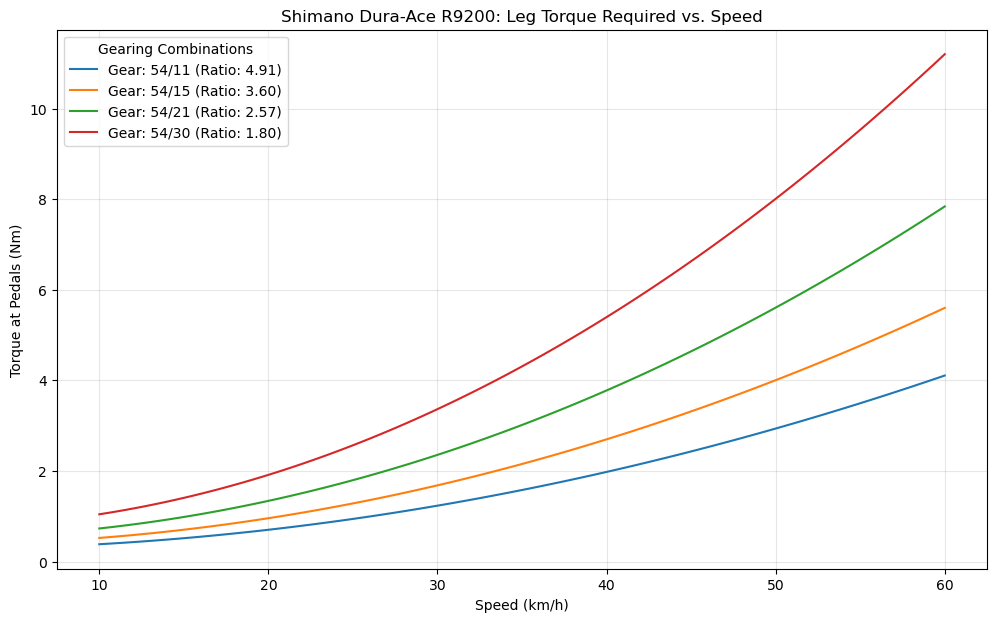

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_bike_torque():
    # --- Constants ---
    mass_total = 80       # Rider + Bike (kg)
    rho = 1.225           # Air density (kg/m^3)
    CdA = 0.32            # Aerodynamic drag area (racing tuck)
    Crr = 0.005           # Rolling resistance (high-end tires)
    g = 9.81
    crank_length = 0.1725 # 172.5mm (Standard Dura-Ace length)
    wheel_radius = 0.335  # 700c wheel with 28mm tire
    
    # --- Dura-Ace R9200 Gearing ---
    front_chainring = 54  # "Big Ring"
    rear_cogs = [11, 15, 21, 30] # Selection from 11-30T cassette
    
    speeds_kmh = np.linspace(10, 60, 100)
    speeds_ms = speeds_kmh / 3.6
    
    plt.figure(figsize=(12, 7))
    
    # Resistance Force = Drag + Rolling
    # F = 0.5 * rho * v^2 * CdA + Crr * m * g
    resistance_force = 0.5 * rho * (speeds_ms**2) * CdA + (Crr * mass_total * g)
    
    # Torque at the REAR WHEEL
    wheel_torque = resistance_force * wheel_radius
    
    for cog in rear_cogs:
        gear_ratio = front_chainring / cog
        
        # Pedal Torque = (Wheel Torque / Gear Ratio) / Mechanical Efficiency (~97%)
        pedal_torque = (wheel_torque / gear_ratio) / 0.97
        
        plt.plot(speeds_kmh, pedal_torque, label=f'Gear: 54/{cog} (Ratio: {gear_ratio:.2f})')

    plt.title("Shimano Dura-Ace R9200: Leg Torque Required vs. Speed")
    plt.xlabel("Speed (km/h)")
    plt.ylabel("Torque at Pedals (Nm)")
    plt.legend(title="Gearing Combinations")
    plt.grid(True, alpha=0.3)
    plt.show()

simulate_bike_torque()